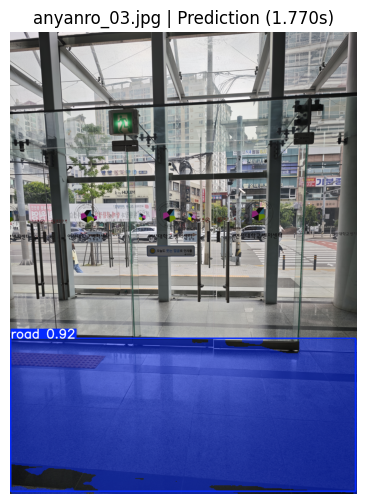

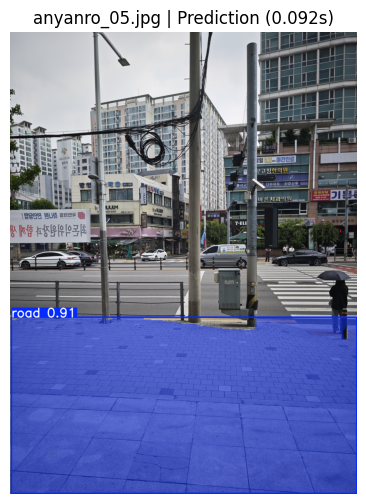

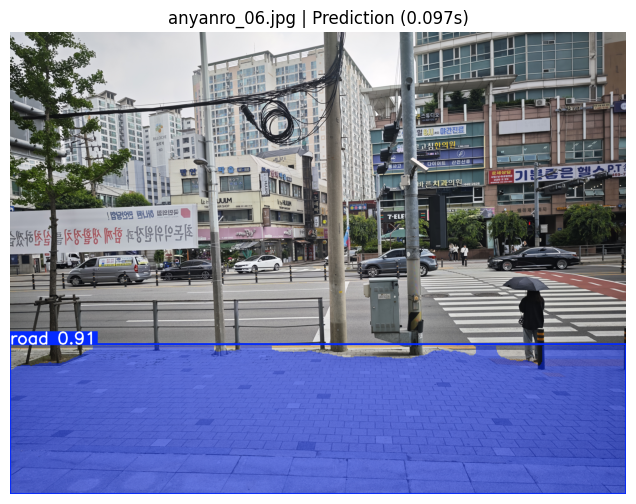

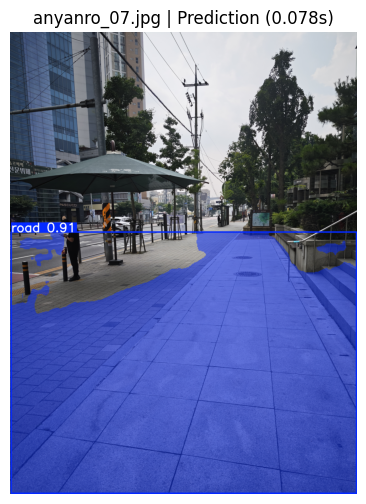

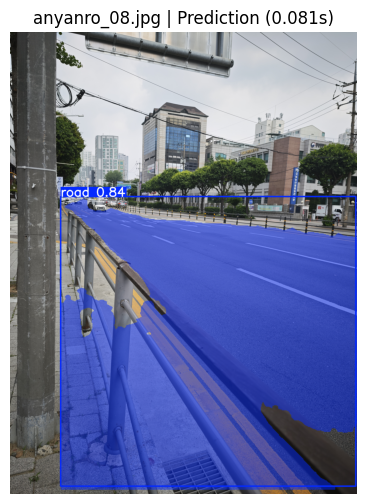

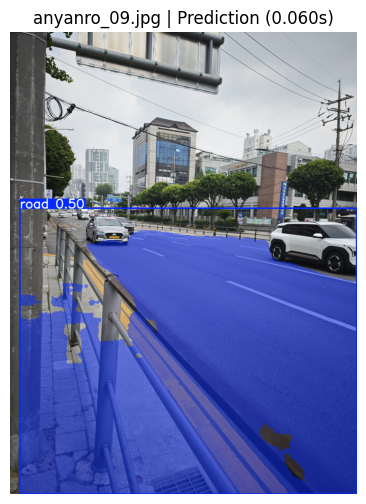

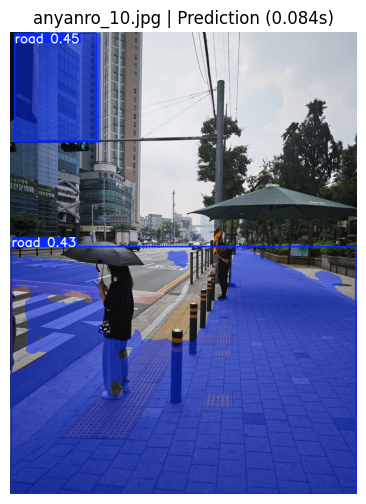

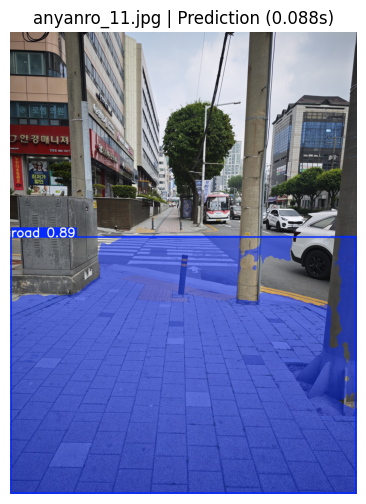

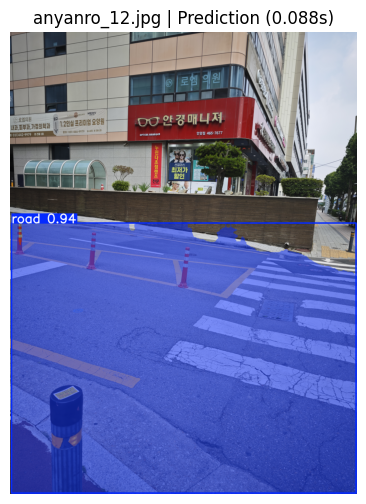

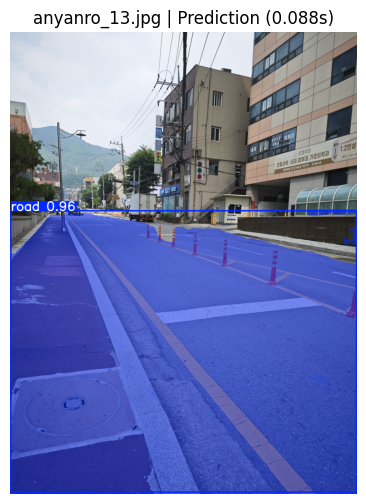

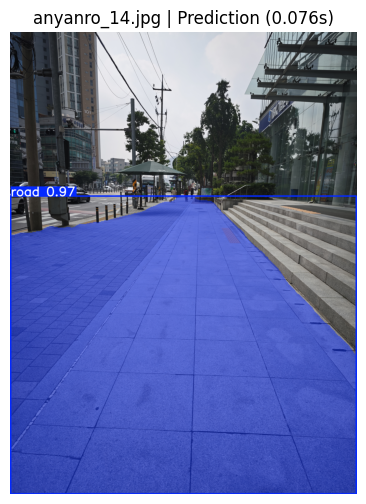

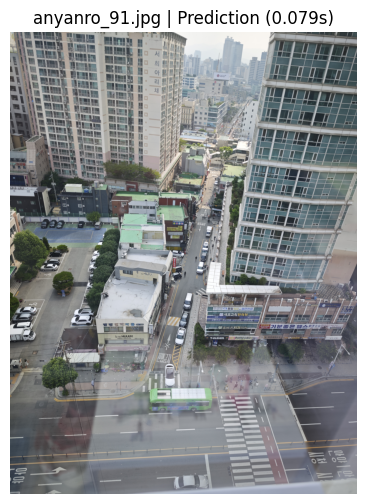

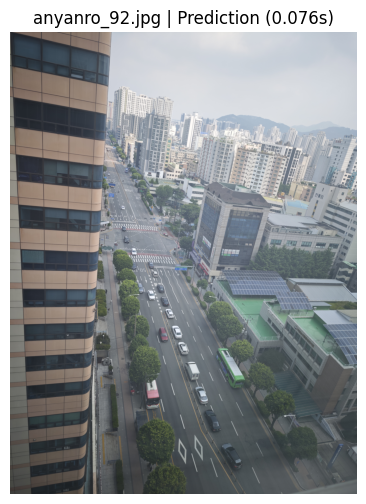

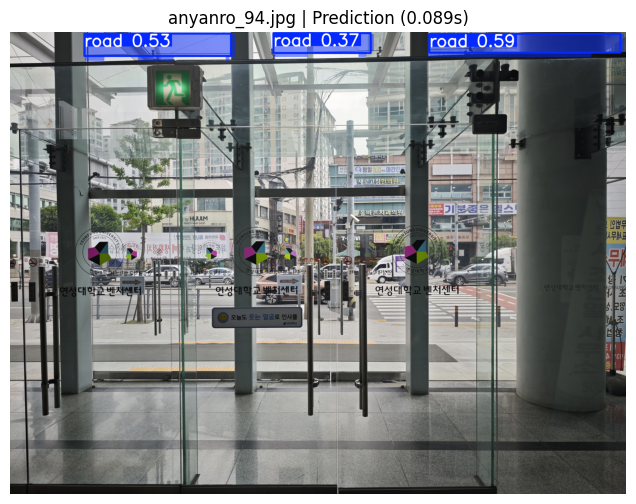

Processed 14 files
Total inference time: 2.847s
Average inference time: 0.203s


In [ ]:
from ultralytics import YOLO
from pathlib import Path
import matplotlib.pyplot as plt
import cv2
import os
import time

model = YOLO("./model/01-yolo11m-road-sg.pt")

exts = {".jpg", ".jpeg", ".png", ".gif"}
image_files = sorted(
    str(p) for p in Path("./test_data_02_anyang").rglob("*")
    if p.is_file() and p.suffix.lower() in exts
)

if not image_files:
    raise FileNotFoundError("No image files found in ./test_data_02_anyang")

total_time = 0.0

for image_file in image_files:
    filename = os.path.basename(image_file)

    start = time.time()
    result = model(image_file, verbose=False)[0]
    elapsed = time.time() - start
    total_time += elapsed

    predicted = cv2.cvtColor(result.plot(), cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(10, 6))
    plt.imshow(predicted)
    plt.title(f"{filename} | Prediction ({elapsed:.3f}s)")
    plt.axis("off")
    plt.show()

print(f"Processed {len(image_files)} files")
print(f"Total inference time: {total_time:.3f}s")
print(f"Average inference time: {total_time / len(image_files):.3f}s")